In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

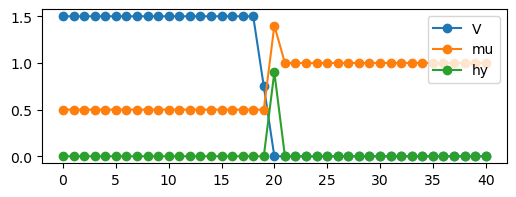

In [2]:
widthS = 20
widthF1 = 1
widthF2 = 20
X, Y = widthS+widthF1+widthF2, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 0.5 * t
muF = 1.4 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS+widthF1] = muF
mu[widthS+widthF1:] = muN

h0 = 0.9 * t
hy = np.zeros_like(mu)

hy[widthS:widthS+widthF1] = h0

U=None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1], hy=hy)

In [4]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=1e-3, maxiter=500, verbose=True, temperature=T)

F0:
Absolute error: 0.04580615253928533
Relative error: 45806152539.285324
Average old: 0j
Average: (0.0027046231436759203-1.287598316326396e-19j)
F_xplus:
Absolute error: 0.3875796446391741
Relative error: 35900953625.44333
Average old: (0.0475+0j)
Average: (0.09132544564254436+6.815862347226839e-19j)
F_xmin:
Absolute error: 0.3936447940371092
Relative error: 24724129350.738464
Average old: (0.05+0j)
Average: (0.09341207900356972+1.8906166684622707e-18j)
F_yplus:
Absolute error: 0.38108886787148316
Relative error: 32663586170.09403
Average old: (-0.04878048780487805+0j)
Average: (-0.09202507322377705+5.857946625142686e-17j)
F_ymin:
Absolute error: 0.3810888678714831
Relative error: 32663586170.094044
Average old: (-0.04878048780487805+0j)
Average: (-0.09202507322377708-5.90029639280213e-17j)
Fuu_xplus:
Absolute error: 0.026445894865804693
Relative error: 26445894865.804695
Average old: 0j
Average: (8.564361655899969e-19-0.0022122257072650082j)
Fuu_xmin:
Absolute error: 0.0264458948658

In [5]:
F, Fuu, Fdd = H.get_correlations()

T/t=0.001, hy/t=0.9


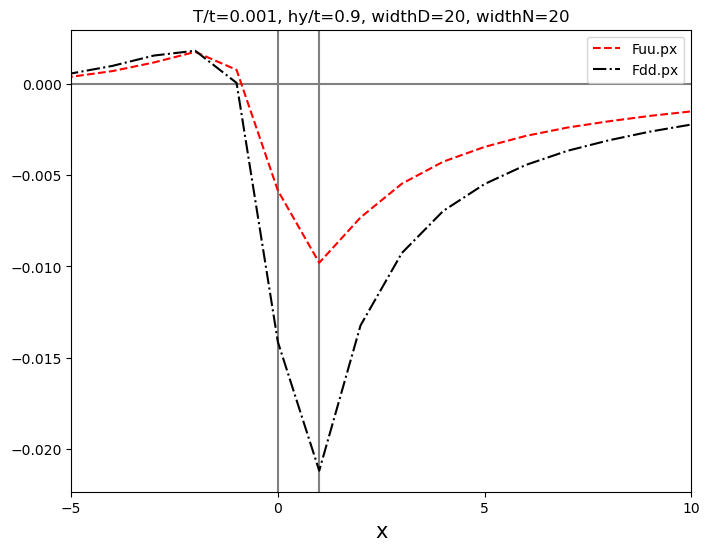

In [8]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

# axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
# axs.plot(x, np.abs(F.px), label=r"px", color='red')
axs.plot(x, np.imag(Fuu.px), "--", label=r"Fuu.px", color='red')
axs.plot(x, np.imag(Fdd.px), "-.", label=r"Fdd.px", color='black')

axs.set_xlabel("x", fontsize=15)

# axs.set_ylim(None, 0.10)
axs.set_xlim(-5, 10)
axs.set_xticks([-5, 0, 5, 10])
axs.set_title(f"T/t={T}, hy/t={h0}, widthD={widthS}, widthN={widthF2}", )
plt.legend()
plt.show()

T/t=0.001, hy/t=0.9


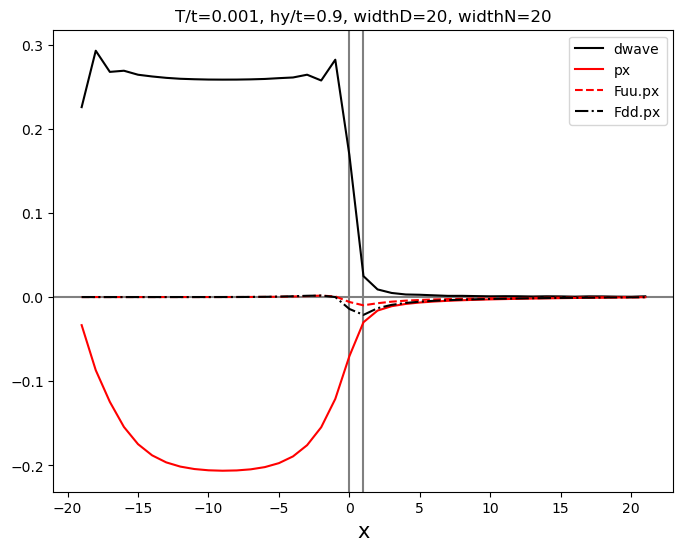

In [11]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
axs.plot(x, np.real(F.px), label=r"px", color='red')
axs.plot(x, np.imag(Fuu.px), "--", label=r"Fuu.px", color='red')
axs.plot(x, np.imag(Fdd.px), "-.", label=r"Fdd.px", color='black')

axs.set_xlabel("x", fontsize=15)

# axs.set_ylim(None, 0.10)
# axs.set_xlim(-5, 10)
# axs.set_xticks([-5, 0, 5, 10])
axs.set_title(f"T/t={T}, hy/t={h0}, widthD={widthS}, widthN={widthF2}", )
plt.legend()
plt.show()

In [8]:
F1, Fuu1, Fdd1 = H.get_correlations()

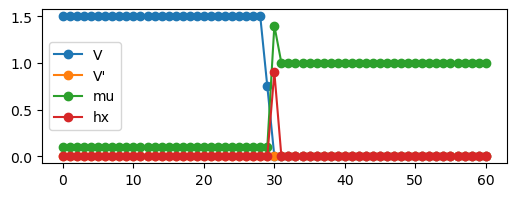

In [9]:
widthS = 30
widthF1 = 1
widthF2 = 30
X, Y = widthS+widthF1+widthF2, 200
lattice = Lattice(X, Y)

t = 1
T = 0.01

muS = 0.1 * t
muF = 1.4 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS+widthF1] = muF
mu[widthS+widthF1:] = muN

h0 = 0.9 * t
hx = np.zeros_like(mu)

hx[widthS:widthS+widthF1] = h0

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2
U=None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

V_prime0 = 1.5 * t * 0
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthS+widthF1] = 0 

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hx, '-o', label='hx')

plt.legend()

In [10]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1], 
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j], 
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j], 
                hx=hx)

In [11]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=0.1, maxiter=100, verbose=True, temperature=T)

F0:
Absolute error: 0.043602799085018205
Relative error: 43602799085.0182
Average old: 0j
Average: (0.0006809381185121562+0j)
F_xplus:
Absolute error: 0.5610750116013175
Relative error: 42242414904.94851
Average old: (0.04833333333333333+0j)
Average: (0.09967753961027576+0j)
F_xmin:
Absolute error: 0.5648215776409489
Relative error: 22218445552.13971
Average old: (0.05+0j)
Average: (0.10102848645055142+0j)
F_yplus:
Absolute error: 0.5545354920752256
Relative error: 29527208303.409924
Average old: (-0.04918032786885246+0j)
Average: (-0.09979484166429523+3.161291127540806e-17j)
F_ymin:
Absolute error: 0.5545354920752256
Relative error: 29527208303.409924
Average old: (-0.04918032786885246+0j)
Average: (-0.09979484166429523-3.161291127540806e-17j)
Fuu_xplus:
Absolute error: 0.031396952800502094
Relative error: 31396952800.502094
Average old: 0j
Average: (0.0019939657633276805+0j)
Fuu_xmin:
Absolute error: 0.03139695280050267
Relative error: 31396952800.50267
Average old: 0j
Average: (-0.0

In [12]:
F, Fuu, Fdd = H.get_correlations()


T/t=0.01, hz/t=0.9


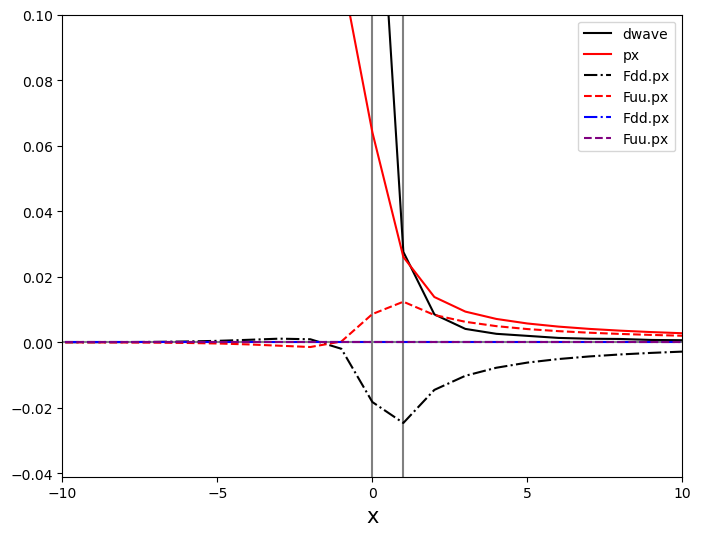

In [13]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
# axs.set_title(f"T/t={T}, hz/t={h0}")
print(f"T/t={T}, hz/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
axs.plot(x, np.abs(F.px), label=r"px", color='red')
axs.plot(x, np.real(Fdd.px), "-.", label=r"Fdd.px", color='black')
axs.plot(x, np.real(Fuu.px), "--", label=r"Fuu.px", color='red')
axs.plot(x, np.imag(Fdd.px), "-.", label=r"Fdd.px", color='blue')
axs.plot(x, np.imag(Fuu.px), "--", label=r"Fuu.px", color='purple')

axs.set_xlabel("x", fontsize=15)

axs.set_ylim(None, 0.10)
axs.set_xlim(-10, 10)
axs.set_xticks([-10, -5, 0, 5, 10])
plt.legend()
plt.show()

In [14]:
F2, Fuu2, Fdd2 = H.get_correlations()

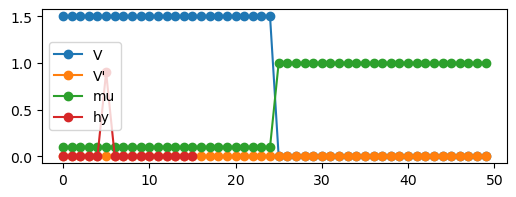

In [15]:
widthS = 25
widthN = 25

X, Y = widthS+widthN, 200
lattice = Lattice(X, Y)

t = 1
T = 0.01

muS = 0.1 * t
muN = 1.0 * t

mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:] = muN

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U=None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0

V_prime0 = 1.5 * t * 0
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthS+widthF1] = 0 

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [16]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1], 
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j], 
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j])

In [17]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=0.1, maxiter=100, verbose=True, temperature=T)

F0:
Absolute error: 0.06924111143465138
Relative error: 69241111434.65137
Average old: 0j
Average: (0.004291964687512289+0j)
F_xplus:
Absolute error: 0.5130083080856539
Relative error: 80631405436.57498
Average old: (0.04897959183673469+0j)
Average: (0.10305854671525742+0j)
F_xmin:
Absolute error: 0.5208432732112342
Relative error: 54770980738.4699
Average old: (0.0510204081632653+0j)
Average: (0.10705418203722081+0j)
F_yplus:
Absolute error: 0.5139278885191872
Relative error: 83728633003.28253
Average old: (-0.05+0j)
Average: (-0.10644488966828247+1.8605535882373794e-17j)
F_ymin:
Absolute error: 0.5139278885191872
Relative error: 83728633003.28253
Average old: (-0.05+0j)
Average: (-0.10644488966828247-1.8605535882373794e-17j)
Fuu_xplus:
Absolute error: 2.7728977205413415e-17
Relative error: 2.7728977205413413e-05
Average old: 0j
Average: (4.288972520225101e-19+0j)
Fuu_xmin:
Absolute error: 3.2292978058908787e-17
Relative error: 3.229297805890878e-05
Average old: 0j
Average: (-3.698263

In [18]:
F, Fuu, Fdd = H.get_correlations()


T/t=0.01, hz/t=0.9


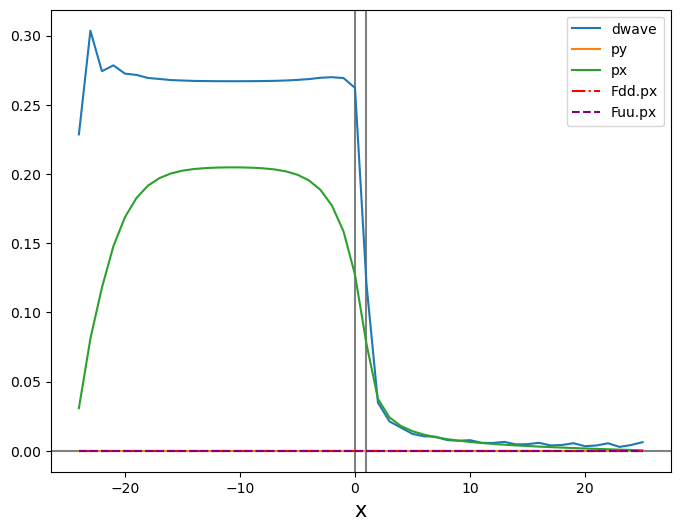

In [19]:
x = np.arange(-widthS, widthN) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
# axs.set_title(f"T/t={T}, hz/t={h0}")
print(f"T/t={T}, hz/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

# axs.plot(x, np.abs(F.swave), label=r"swave",)
axs.plot(x, np.abs(F.dwave), label=r"dwave")
axs.plot(x, np.abs(F.py), label=r"py")
axs.plot(x, np.abs(F.px), label=r"px")
axs.plot(x, np.abs(Fdd.px), "-.", label=r"Fdd.px", color='red')
axs.plot(x, np.abs(Fuu.px), "--", label=r"Fuu.px", color='purple')

axs.set_xlabel("x", fontsize=15)
plt.legend()
plt.show()